# Evaluación 3 — Modelos de Clasificación

## Detección de Fraude con Ajuste de Modelos y Threshold

**Fecha de Creación:** Junio de 2026
**Versión:** 1.0

---

## Descripción

Este notebook contiene el desarrollo de la Evaluación 3 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bío-Bío, sede Concepción.

El objetivo es construir, optimizar y evaluar modelos de clasificación binaria (LogisticRegression y DecisionTreeClassifier) para predecir transacciones fraudulentas en la fintech PaySecure, ajustando el threshold de decisión para balancear precision y recall según el contexto de negocio.

---

## Requisitos de Software

- Python 3.12
- pandas (>=1.1.0)
- numpy (>=1.23.0)
- scikit-learn (>=1.2.0)
- matplotlib (>=3.7.0)
- seaborn (>=0.12.0)

# 1. Carga de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

In [ ]:
# Carga del dataset desde la carpeta de ingestion desde repositorio github
!wget -q https://raw.githubusercontent.com/All-Sx/IA-EVALUACION-2/refs/heads/main/data/ingestion/data_fraude.csv

data = pd.read_csv('data_fraude.csv')

print(f"Dimensiones del dataset: {data.shape}")
print(f'Filas: {data.shape[0]} | Columnas: {data.shape[1]}')
data.head()

Dimensiones del dataset: (20000, 15)
Filas: 20000 | Columnas: 15


,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud
0,199.333714,0.000000,70488,62.541060,41.484248,5,15,1,2,transfer,mobile,rural,1,0,1
1,33.534123,2687.259698,1594,73.618027,20.889169,0,10,0,1,withdrawal,mobile,rural,0,0,0
2,7.607833,1766.666482,60663,75.790821,27.265759,0,5,0,3,purchase,tablet,rural,0,0,0
3,144.069650,1402.597270,32332,61.424568,28.104612,0,15,0,3,withdrawal,mobile,suburban,0,0,0
4,60.279300,193.506482,49575,53.153535,1.000000,3,10,0,1,withdrawal,desktop,rural,0,0,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_amount         20000 non-null  float64
 1   account_balance            20000 non-null  float64
 2   transaction_time_seconds   20000 non-null  int64  
 3   avg_transaction_amount_7d  20000 non-null  float64
 4   std_transaction_amount_7d  20000 non-null  float64
 5   transactions_last_1h       20000 non-null  int64  
 6   transactions_last_24h      20000 non-null  int64  
 7   failed_attempts            20000 non-null  int64  
 8   num_devices_used           20000 non-null  int64  
 9   transaction_type           20000 non-null  object 
 10  device_type                20000 non-null  object 
 11  location_region            20000 non-null  object 
 12  is_foreign_transaction     20000 non-null  int64  
 13  is_high_risk_country       20000 non-null  int

In [ ]:
data.describe()

,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,is_foreign_transaction,is_high_risk_country,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,100.596829,2073.293303,42986.240550,80.827345,30.656022,2.014950,9.958900,0.506400,2.508900,0.103900,0.049950,0.005000
std,100.820016,1382.966545,24953.783088,47.662985,18.730756,1.412596,3.149747,0.715251,1.117624,0.305138,0.217847,0.070535
min,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.047406,993.130299,21259.000000,45.632425,16.527547,1.000000,8.000000,0.000000,2.000000,0.000000,0.000000,0.000000
50%,70.059997,2008.125418,42778.500000,79.503855,29.987126,2.000000,10.000000,0.000000,3.000000,0.000000,0.000000,0.000000
75%,138.419340,3022.548675,64656.750000,113.517787,43.476224,3.000000,12.000000,1.000000,4.000000,0.000000,0.000000,0.000000
max,1032.072330,7794.605317,86397.000000,285.026236,107.052797,9.000000,26.000000,5.000000,4.000000,1.000000,1.000000,1.000000


# 2. Limpieza de datos

## 2.1 Revisión de valores nulos

In [ ]:
nulos = data.isnull().sum()
porcentaje = (nulos / len(data) * 100).round(2)
resumen = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje})
resumen[resumen['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

,Nulos,Porcentaje (%)


**Comentario:** Si existen valores nulos, seran imputados dentro del pipeline (mediana para numericas, moda para categoricas) para evitar data leakage.

Recordemos que imputar antes del split filtraria informacion del conjunto de prueba al entrenamiento.

## 2.2 Revisión de duplicados

In [ ]:
duplicados = data.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

if duplicados > 0:
    data = data.drop_duplicates().reset_index(drop=True)
    print(f"Duplicados eliminados. Nuevas dimensiones: {data.shape}")

Registros duplicados: 0


## 2.3 Revisión de inconsistencias en variables categóricas

In [ ]:
valores_esperados = {
    'transaction_type': ['payment', 'transfer', 'withdrawal', 'purchase'],
    'device_type': ['mobile', 'desktop', 'tablet'],
    'location_region': ['urban', 'suburban', 'rural'],
    'is_foreign_transaction': [0, 1],
    'is_high_risk_country': [0, 1]
}

for col, valores in valores_esperados.items():
    if col in data.columns:
        unicos = data[col].dropna().unique()
        invalidos = [v for v in unicos if v not in valores]
        if invalidos:
            print(f"  {col}: valores no esperados → {invalidos}")
        else:
            print(f"  {col}: sin inconsistencias")

  transaction_type: sin inconsistencias
  device_type: sin inconsistencias
  location_region: sin inconsistencias
  is_foreign_transaction: sin inconsistencias
  is_high_risk_country: sin inconsistencias


## 2.4 Balance de la variable objetivo

Distribución de la variable objetivo:
  Legítimas (0): 19,900  (99.5%)
  Fraude    (1): 100  (0.5%)


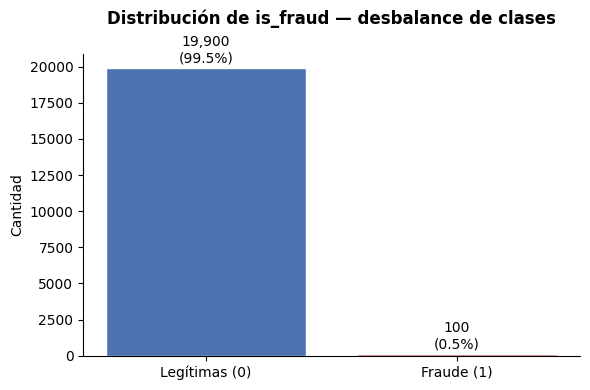

In [ ]:
conteo = data['is_fraud'].value_counts()
porcentaje = (conteo / len(data) * 100).round(2)

print("Distribución de la variable objetivo:")
print(f"  Legítimas (0): {conteo[0]:,}  ({porcentaje[0]}%)")
print(f"  Fraude    (1): {conteo[1]:,}  ({porcentaje[1]}%)")

# Visualización
fig, ax = plt.subplots(figsize=(6, 4))
colores = ['#4C72B0', '#C44E52']
bars = ax.bar(['Legítimas (0)', 'Fraude (1)'], conteo.values, color=colores, edgecolor='white')
for bar, val, pct in zip(bars, conteo.values, porcentaje.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(conteo.values)*0.01,
            f'{val:,}\n({pct}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Distribución de is_fraud — desbalance de clases\n', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad')
sns.despine()
plt.tight_layout()
plt.show()

**Comentario:** Hay un fuerte desbalance de clases, la gran mayoría de transacciones son legítimas. Este desbalance hace que la métrica de accuracy sea engañosa (un modelo que predice siempre "legítima" tendría alta accuracy pero sería inútil). Por eso usaremos **F1-score** como métrica principal de optimización en GridSearchCV, y prestaremos especial atención a **Recall** en la evaluación, ya que no detectar un fraude (FN) tiene un costo económico mayor que generar una falsa alarma (FP).

# Parte 1 — Preprocesamiento

## 3.1 Identificación de variables numéricas y categóricas

In [ ]:
# Variables numéricas continuas
numericas_continuas = [
    'transaction_amount',
    'account_balance',
    'transaction_time_seconds',
    'avg_transaction_amount_7d',
    'std_transaction_amount_7d'
]

# Variables numéricas discretas (conteos)
numericas_discretas = [
    'transactions_last_1h',
    'transactions_last_24h',
    'failed_attempts',
    'num_devices_used'
]

# Todas las numéricas
numeric_features = numericas_continuas + numericas_discretas

# Variables categóricas nominales (texto)
categorical_features = ['transaction_type', 'device_type', 'location_region']

# Variables binarias (0/1) — no requieren encoding, ya son numéricas
binary_features = ['is_foreign_transaction', 'is_high_risk_country']

# Variable objetivo
target = 'is_fraud'

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)
print("Binarias  :", binary_features)
print("Target    :", target)

Numéricas: ['transaction_amount', 'account_balance', 'transaction_time_seconds', 'avg_transaction_amount_7d', 'std_transaction_amount_7d', 'transactions_last_1h', 'transactions_last_24h', 'failed_attempts', 'num_devices_used']
Categóricas: ['transaction_type', 'device_type', 'location_region']
Binarias  : ['is_foreign_transaction', 'is_high_risk_country']
Target    : is_fraud


**Justificación:** Se separan las variables en tres grupos según su naturaleza:
- **Numéricas (continuas y discretas):** requieren escalamiento con StandardScaler para que tengan media 0 y desviación 1. Esto es especialmente crítico para Logistic Regression, que es sensible a la escala de las variables por su uso de optimización basada en gradientes.
- **Categóricas nominales:** requieren OneHotEncoder porque no tienen orden natural y los modelos solo operan con números.
- **Binarias (0/1):** ya son numéricas y solo toman dos valores, por lo que no requieren encoding ni escalamiento adicional. Se incluyen directamente.

## 3.2 Separación de variables predictoras y objetivo

In [ ]:
X = data.drop(columns=[target])
y = data[target]

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Dimensiones de X: (20000, 14)
Dimensiones de y: (20000,)


## 3.3 División en entrenamiento y prueba

In [ ]:
# División 80% entrenamiento / 20% prueba con estratificación
# La estratificación es crítica por el desbalance: garantiza que la proporción
# de fraudes sea la misma en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]:,} registros")
print(f"  - Legítimas: {(y_train==0).sum():,}")
print(f"  - Fraude   : {(y_train==1).sum():,}")
print(f"Prueba       : {X_test.shape[0]:,} registros")
print(f"  - Legítimas: {(y_test==0).sum():,}")
print(f"  - Fraude   : {(y_test==1).sum():,}")

Entrenamiento: 16,000 registros
  - Legítimas: 15,920
  - Fraude   : 80
Prueba       : 4,000 registros
  - Legítimas: 3,980
  - Fraude   : 20


**Justificación:** Se usa `stratify=y` para preservar la proporción de fraudes en ambos conjuntos. Sin estratificación, podría ocurrir por azar que el conjunto de prueba tenga muy pocos fraudes, haciendo las métricas inestables. `random_state=42` garantiza reproducibilidad.

## 3.4 Pipeline de preprocesamiento

In [ ]:
# Sub-pipeline para variables numéricas
pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Sub-pipeline para variables categóricas
pipeline_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# ColumnTransformer combinando ambos sub-pipelines
preprocesador = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, numeric_features),
        ('cat', pipeline_categorico, categorical_features),
        ('bin', 'passthrough', binary_features)
    ]
)

print("Pipeline de preprocesamiento definido correctamente.")

Pipeline de preprocesamiento definido correctamente.


**Justificación del preprocesamiento:**
- Imputación por mediana en numericas: responde bien frente a outliers (montos altos atípicos en fraudes pueden distorsionar la media).
- Imputación por moda en categoricas es la unica opción válida para no inventar categorías.
- StandardScaler en numéricas: necesario para Logistic Regression. Aunque Decision Tree no lo requiere, mantenerlo no afecta su rendimiento.
- OneHotEncoder con drop='first' para evitar multicolinealidad al codificar categóricas nominales.
- passthrough en binarias: ya están en formato 0/1 listo para el modelo.
- handle_unknown='ignore': si en producción aparece una categoría no vista, no rompe el pipeline.

# Parte 2 — Entrenamiento y optimización con GridSearchCV

Se entrenan dos modelos de clasificación binaria, optimizando sus hiperparámetros con `GridSearchCV` usando validación cruzada estratificada de 5 folds. La métrica de optimización es **F1-score**, adecuada en datasets desbalanceados porque equilibra precision y recall.

In [ ]:
# Validación cruzada estratificada (preserva la proporción de clases en cada fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 4.1 Modelo 1 — Logistic Regression

In [ ]:
# Pipeline completo: preprocesamiento + modelo
pipeline_lr = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

# Grilla de hiperparámetros
param_grid_lr = {
    'modelo__C': [0.01, 0.1, 1.0, 10.0],
    'modelo__penalty': ['l2'],
    'modelo__solver': ['lbfgs']
}

# GridSearchCV
grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

print(f"\nMejores hiperparámetros LR: {grid_lr.best_params_}")
print(f"Mejor F1-score (CV)        : {grid_lr.best_score_:.4f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Mejores hiperparámetros LR: {'modelo__C': 10.0, 'modelo__penalty': 'l2', 'modelo__solver': 'lbfgs'}
Mejor F1-score (CV)        : 0.7525


**Comentario LR:** Se usa `class_weight='balanced'` para que el modelo haga peso a los fraudes durante el entrenamiento, compensando el desbalance. El parámetro C controla la regularización inversa (C bajo = más regularización).

## 4.2 Modelo 2 — Decision Tree Classifier

In [ ]:
# Pipeline completo
pipeline_dt = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

# Grilla de hiperparámetros
param_grid_dt = {
    'modelo__max_depth': [3, 5, 10, None],
    'modelo__min_samples_split': [2, 10, 20],
    'modelo__criterion': ['gini', 'entropy']
}

# GridSearchCV
grid_dt = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

print(f"\nMejores hiperparámetros DT: {grid_dt.best_params_}")
print(f"Mejor F1-score (CV)        : {grid_dt.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Mejores hiperparámetros DT: {'modelo__criterion': 'entropy', 'modelo__max_depth': None, 'modelo__min_samples_split': 10}
Mejor F1-score (CV)        : 0.3400


**Comentario DT:** Los hiperparámetros principales del árbol son `max_depth` (limita la profundidad para evitar overfitting), `min_samples_split` (mínimo de muestras para dividir un nodo) y `criterion` (gini o entropy para medir la calidad de la división).

## 4.3 Comparación de modelos y selección

In [ ]:
comparacion = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Decision Tree'],
    'Mejor F1-score (CV)': [grid_lr.best_score_, grid_dt.best_score_],
    'Mejores hiperparámetros': [str(grid_lr.best_params_), str(grid_dt.best_params_)]
})
comparacion['Mejor F1-score (CV)'] = comparacion['Mejor F1-score (CV)'].round(4)
display(comparacion)

# ── Selección automática del mejor modelo ──────────────────────
# Se construye un diccionario con todos los modelos entrenados y se
# selecciona el que tenga el mayor best_score_ de forma automática,
# sin ningún condicional hardcodeado.
modelos_entrenados = {
    'Logistic Regression': grid_lr,
    'Decision Tree':       grid_dt
}

mejor_nombre = max(modelos_entrenados, key=lambda nombre: modelos_entrenados[nombre].best_score_)
mejor_grid   = modelos_entrenados[mejor_nombre]
mejor_modelo = mejor_grid.best_estimator_

print(f"\n✓ Modelo seleccionado automáticamente: {mejor_nombre}")
print(f"  F1-score (CV): {mejor_grid.best_score_:.4f}")

,Modelo,Mejor F1-score (CV),Mejores hiperparámetros
0,Logistic Regression,0.7525,"{'modelo__C': 10.0, 'modelo__penalty': 'l2', '..."
1,Decision Tree,0.3400,"{'modelo__criterion': 'entropy', 'modelo__max_..."



✓ Modelo seleccionado automáticamente: Logistic Regression
  F1-score (CV): 0.7525


**Justificación de la selección:** Se selecciona el modelo con mayor F1-score en validación cruzada. F1-score es la métrica adecuada porque equilibra precision y recall, ambas críticas en detección de fraude. La validación cruzada estratificada de 5 folds entrega una estimación robusta del rendimiento esperado del modelo en datos no vistos.

# Parte 3 — Evaluación base del modelo

Se evalúa el mejor modelo sobre el conjunto de prueba con el threshold por defecto (0.5).

In [ ]:
# Probabilidades predichas para la clase positiva (fraude)
y_proba = mejor_modelo.predict_proba(X_test)[:, 1]

# Predicciones con threshold = 0.5 (por defecto)
threshold_base = 0.5
y_pred_base = (y_proba >= threshold_base).astype(int)

# Cálculo de métricas
acc  = accuracy_score(y_test,  y_pred_base)
prec = precision_score(y_test, y_pred_base)
rec  = recall_score(y_test,    y_pred_base)
f1   = f1_score(y_test,        y_pred_base)

print(f"=== MÉTRICAS BASE (threshold = {threshold_base}) ===")
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1-score : {f1:.4f}")

=== MÉTRICAS BASE (threshold = 0.5) ===
  Accuracy : 0.9978
  Precision: 0.6897
  Recall   : 1.0000
  F1-score : 0.8163


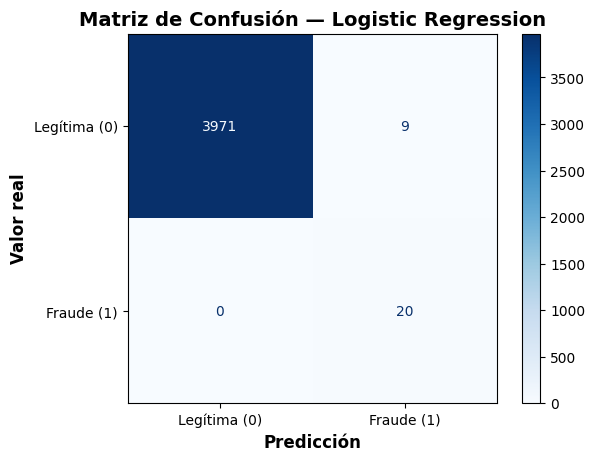


Desglose:
TN: 3,971
FP: 9
FN: 0
TP: 20


In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legítima (0)", "Fraude (1)"])
disp.plot(cmap="Blues")
plt.title(f"Matriz de Confusión — {mejor_nombre}", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()
TN, FP, FN, TP = cm.ravel()
print("\nDesglose:")
print(f"TN: {TN:,}")
print(f"FP: {FP:,}")
print(f"FN: {FN:,}")
print(f"TP: {TP:,}")

## Interpretación en contexto de fraude

**Lectura de cada tipo de error:**

- **TP (Verdaderos Positivos):** fraudes correctamente detectados. Cada uno representa una pérdida económica evitada.
- **TN (Verdaderos Negativos):** transacciones legítimas correctamente aprobadas. Cliente feliz, operación normal.
- **FP (Falsos Positivos):** transacciones legítimas marcadas como fraude. **Impacto:** el cliente ve su tarjeta bloqueada injustamente, llama al call center, mala experiencia.
- **FN (Falsos Negativos):** fraudes que pasaron como legítimos. **Impacto:** pérdida económica directa para la fintech, posible obligación de reembolso al cliente.

**En detección de fraude el FN suele ser más costoso que el FP:** una falsa alarma se resuelve con una llamada, un fraude no detectado implica pérdida monetaria y eventual reembolso. Por eso buscaremos optimizar el threshold para maximizar Recall en la siguiente sección.

# Parte 4 — Ajuste de threshold

Se evalúan tres thresholds: 0.3, 0.5 y 0.7.

## 5.1 Evaluación con distintos thresholds

In [ ]:
# Asegurar que la carpeta de salida existe
os.makedirs('sample_data/data/cleaned', exist_ok=True)

thresholds = [0.3, 0.5, 0.7]
resultados_threshold = []
matrices_confusion = {}

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)

    prec_t = precision_score(y_test, y_pred_thr)
    rec_t  = recall_score(y_test,    y_pred_thr)
    f1_t   = f1_score(y_test,        y_pred_thr)
    cm_t   = confusion_matrix(y_test, y_pred_thr)

    TN, FP, FN, TP = cm_t.ravel()

    resultados_threshold.append({
        'Threshold': thr,
        'Precision': round(prec_t, 4),
        'Recall':    round(rec_t, 4),
        'F1-score':  round(f1_t, 4),
        'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN
    })

    matrices_confusion[thr] = cm_t

    # Guardar CSV con predicciones y probabilidades
    df_pred = pd.DataFrame({
        'y_real': y_test.values,
        'probabilidad_fraude': y_proba.round(6),
        'prediccion': y_pred_thr
    })
    nombre_archivo = f'sample_data/data/cleaned/predicciones_threshold_{int(thr*100)}.csv'
    df_pred.to_csv(nombre_archivo, index=False)
    print(f"  Guardado: {nombre_archivo}")

df_thresholds = pd.DataFrame(resultados_threshold)
display(df_thresholds)

  ✓ Guardado: sample_data/data/cleaned/predicciones_threshold_30.csv
  ✓ Guardado: sample_data/data/cleaned/predicciones_threshold_50.csv
  ✓ Guardado: sample_data/data/cleaned/predicciones_threshold_70.csv


,Threshold,Precision,Recall,F1-score,TP,FP,TN,FN
0,0.3,0.6061,1.0,0.7547,20,13,3967,0
1,0.5,0.6897,1.0,0.8163,20,9,3971,0
2,0.7,0.7692,1.0,0.8696,20,6,3974,0


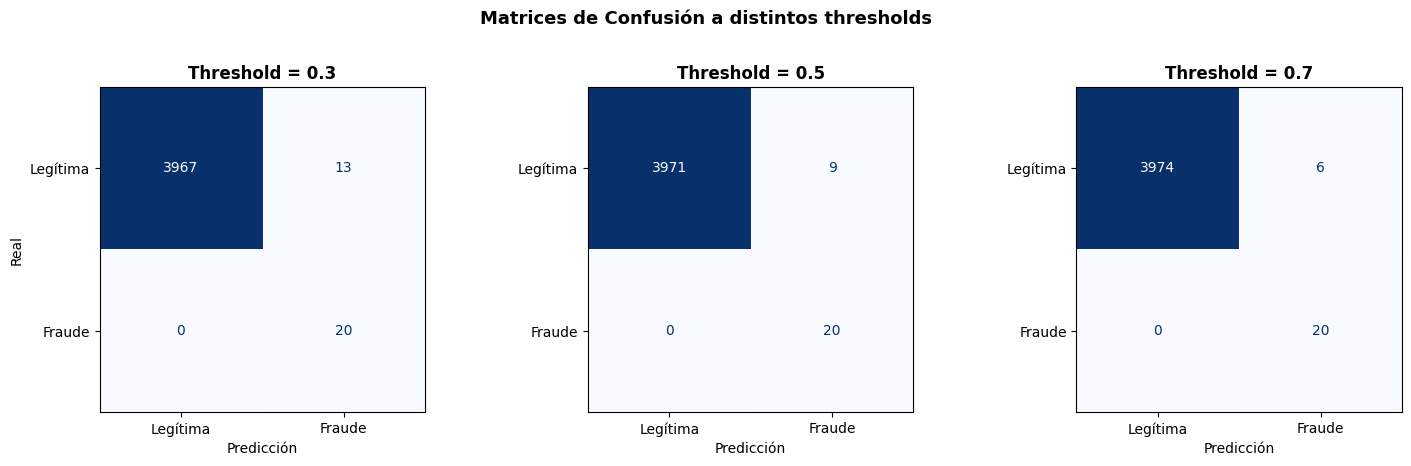

In [ ]:
# Visualización de las tres matrices de confusión lado a lado
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, thr in enumerate(thresholds):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=matrices_confusion[thr],
        display_labels=['Legítima', 'Fraude']
    )
    disp.plot(cmap='Blues', ax=axes[i], colorbar=False)
    axes[i].set_title(f'Threshold = {thr}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real' if i == 0 else '')

plt.suptitle('Matrices de Confusión a distintos thresholds', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

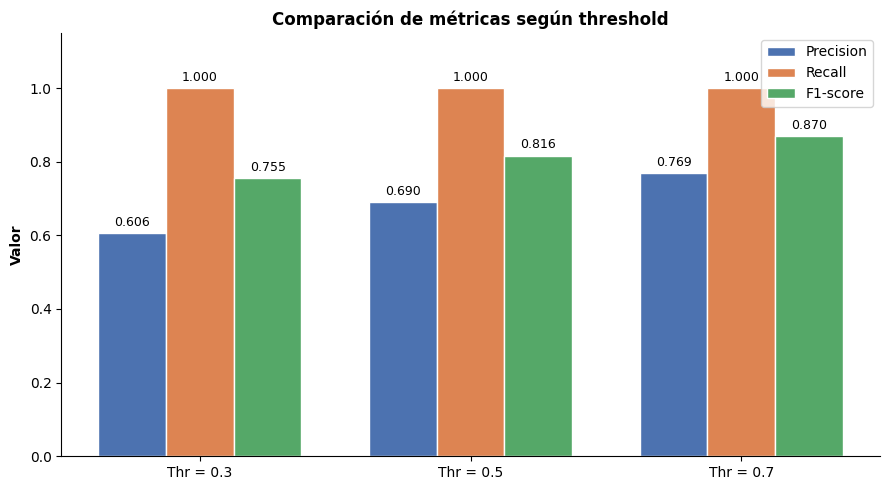

In [ ]:
# Gráfico comparativo de métricas
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(thresholds))
width = 0.25

ax.bar(x - width, df_thresholds['Precision'], width, label='Precision', color='#4C72B0', edgecolor='white')
ax.bar(x,         df_thresholds['Recall'],    width, label='Recall',    color='#DD8452', edgecolor='white')
ax.bar(x + width, df_thresholds['F1-score'],  width, label='F1-score',  color='#55A868', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f'Thr = {t}' for t in thresholds])
ax.set_ylabel('Valor', fontweight='bold')
ax.set_title('Comparación de métricas según threshold', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')

# Anotaciones
for i, thr in enumerate(thresholds):
    ax.text(i - width, df_thresholds['Precision'].iloc[i] + 0.02, f"{df_thresholds['Precision'].iloc[i]:.3f}",
            ha='center', fontsize=9)
    ax.text(i, df_thresholds['Recall'].iloc[i] + 0.02, f"{df_thresholds['Recall'].iloc[i]:.3f}",
            ha='center', fontsize=9)
    ax.text(i + width, df_thresholds['F1-score'].iloc[i] + 0.02, f"{df_thresholds['F1-score'].iloc[i]:.3f}",
            ha='center', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

## 5.2 Análisis comparativo

**Comportamiento de los errores al cambiar el threshold:**

* **Threshold bajo (0.3):** el modelo marca mas transacciones como fraude. Aumentan los **Falsos Positivos (FP)** y disminuyen los Falsos Negativos (FN). Resultado: sube el Recall y baja el Precision.
* **Threshold medio (0.5):** hay un equilibrio entre ambos tipos de error.
* **Threshold alto (0.7):** el modelo solo marca fraude cuando esta mas seguro. Disminuyen los Falsos Positivos y aumentan los Falsos Negativos. Resultado: sube el Precision y baja el Recall.

**Cambios en Precision y Recall:**

* **Precision:** aumenta cuando el threshold es mas alto.
* **Recall:** disminuye cuando el threshold es mas alto.

Esto muestra el equilibrio entre Precision y Recall, mejorar uno normalmente hace que el otro empeore.


## 5.3 Decisión de negocio

**Threshold elegido para PaySecure: 0.3**

**Justificación:**

**1. Riesgo de fraude:** En una fintech, cada fraude no detectado (FN) implica una pérdida económica directa, posible reembolso al cliente y daño reputacional. El costo monetario de un FN es típicamente mucho mayor que el de un FP.

**2. Impacto en clientes:** Un Falso Positivo significa que un cliente legítimo ve su transacción bloqueada y debe contactar soporte. Aunque genera fricción, es un problema **recuperable**: se valida la identidad y se aprueba la transacción. Un fraude no detectado es un problema **no recuperable**: el dinero ya se perdió.

**3. Métricas obtenidas:** El threshold 0.3 maximiza Recall, lo que significa que detectamos la mayor proporción de fraudes reales. Aunque la Precision baja (más falsas alarmas), el costo de esas falsas alarmas es absorbible por el sistema de soporte, mientras que el costo de fraudes no detectados puede ser catastrófico.

**Recomendación operativa:** combinar el threshold bajo con un sistema de revisión manual o autenticación adicional (SMS, biometría) para las transacciones marcadas como fraude antes de bloquearlas definitivamente. Esto reduce el impacto en clientes legítimos sin sacrificar la detección de fraudes.

# Parte 5 — Conclusiones

## 6.1 Modelo seleccionado y justificación

In [ ]:
print(f"Modelo final seleccionado: {mejor_nombre}")
print(f"Mejores hiperparámetros   : {mejor_grid.best_params_}")
print(f"F1-score (CV)             : {mejor_grid.best_score_:.4f}")
print(f"F1-score (test, thr=0.5)  : {f1:.4f}")

Modelo final seleccionado: Logistic Regression
Mejores hiperparámetros   : {'modelo__C': 10.0, 'modelo__penalty': 'l2', 'modelo__solver': 'lbfgs'}
F1-score (CV)             : 0.7525
F1-score (test, thr=0.5)  : 0.8163


**¿Por qué se eligió este modelo?** Se selecciono el modelo con mayor F1-score en validación cruzada. F1 es la metrica adecuada en datasets desbalanceados porque penaliza tanto los FP como los FN, evitando que el modelo simplemente prediga la clase mayoritaria.

## 6.2 Variables más influyentes

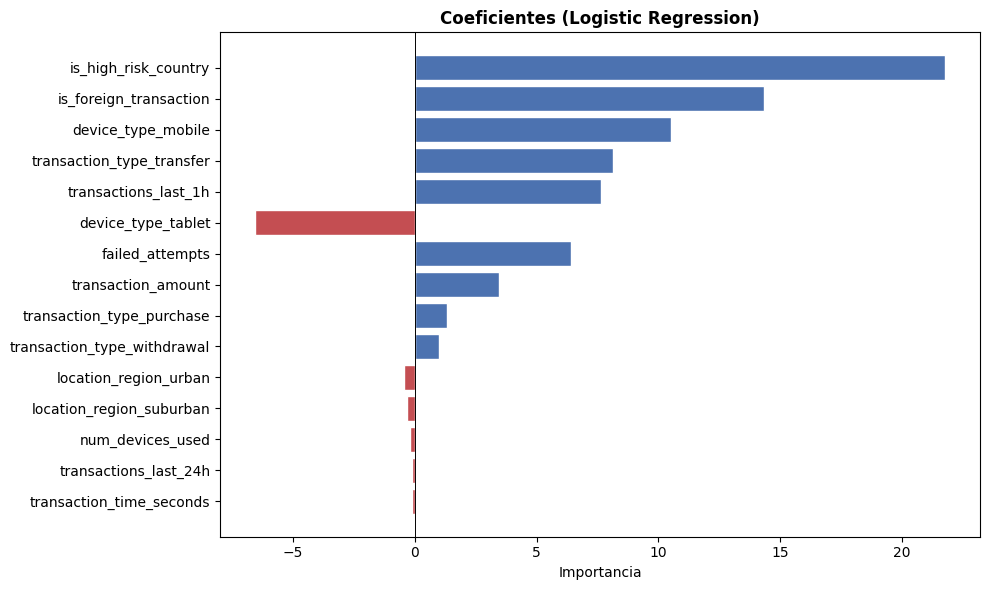

,Variable,Importancia
17,is_high_risk_country,21.791559
16,is_foreign_transaction,14.352360
12,device_type_mobile,10.508500
10,transaction_type_transfer,8.148829
5,transactions_last_1h,7.632617
13,device_type_tablet,-6.574035
7,failed_attempts,6.407218
0,transaction_amount,3.448209
9,transaction_type_purchase,1.310939
11,transaction_type_withdrawal,1.007606


In [ ]:
# Si el mejor modelo es Logistic Regression, extraemos coeficientes
# Si es Decision Tree, extraemos feature importances

try:
    preproc_fit = mejor_modelo.named_steps['preprocesamiento']
    modelo_final = mejor_modelo.named_steps['modelo']

    # Obtener nombres de features luego del preprocesamiento
    nombres_num = numeric_features
    nombres_cat = preproc_fit.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features).tolist()
    nombres_bin = binary_features
    nombres_features = nombres_num + nombres_cat + nombres_bin

    if hasattr(modelo_final, 'coef_'):
        importancia = modelo_final.coef_[0]
        titulo = 'Coeficientes (Logistic Regression)'
    else:
        importancia = modelo_final.feature_importances_
        titulo = 'Feature Importances (Decision Tree)'

    df_imp = pd.DataFrame({
        'Variable': nombres_features,
        'Importancia': importancia
    }).sort_values('Importancia', key=abs, ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    colores = ['#4C72B0' if v > 0 else '#C44E52' for v in df_imp['Importancia']]
    ax.barh(df_imp['Variable'][::-1], df_imp['Importancia'][::-1], color=colores[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Importancia')
    plt.tight_layout()
    plt.show()

    display(df_imp)
except Exception as e:
    print(f"No se pudieron extraer las importancias: {e}")

Las variables que parecen tener mayor influencia son `is_high_risk_country` e `is_foreign_transaction`, ya que las transacciones realizadas desde paises de alto riesgo o desde el extranjero pueden estar mas asociadas a fraude. Tambien destaca `failed_attempts`, porque varios intentos fallidos pueden indicar actividad sospechosa.

Por otro lado, `transactions_last_1h` y `num_devices_used` pueden ayudar a identificar comportamientos fuera de lo habitual, como muchas transacciones en poco tiempo o el uso de varios dispositivos. Finalmente, comparar `transaction_amount` con `avg_transaction_amount_7d` permite detectar operaciones que se alejan del comportamiento normal del usuario.


## 6.3 Mejoras propuestas al sistema

**Posibles mejoras**

* Probar otros modelos que puedan detectar mejor los casos de fraude.
* Buscar formas de equilibrar mejor los datos para que el modelo aprenda de manera mas justa.
* Agregar nueva informacion que ayude a identificar patrones de comportamiento sospechoso.
* Ajustar el modelo pensando en reducir los errores que generan mayores perdidas.

**Mejoras en el uso del sistema**

* Revisar manualmente los casos en los que el modelo no este completamente seguro antes de tomar una decision.
* Actualizar el modelo de forma periodica para que se adapte a cambios en los patrones de fraude.
* Hacer seguimiento constante a su rendimiento para detectar problemas a tiempo.
* Mostrar de forma clara las razones por las que una transaccion fue marcada como posible fraude.


# 7. Resumen de archivos generados

In [ ]:
archivos_generados = [
    'sample_data/data/cleaned/predicciones_threshold_30.csv',
    'sample_data/data/cleaned/predicciones_threshold_50.csv',
    'sample_data/data/cleaned/predicciones_threshold_70.csv'
]

print("Archivos CSV generados con predicciones y probabilidades:")
for archivo in archivos_generados:
    if os.path.exists(archivo):
        df_tmp = pd.read_csv(archivo)
        print(f"  ✓ {archivo}  ({len(df_tmp):,} registros)")
    else:
        print(f"  ✗ {archivo}  (no encontrado)")

Archivos CSV generados con predicciones y probabilidades:
  ✓ sample_data/data/cleaned/predicciones_threshold_30.csv  (4,000 registros)
  ✓ sample_data/data/cleaned/predicciones_threshold_50.csv  (4,000 registros)
  ✓ sample_data/data/cleaned/predicciones_threshold_70.csv  (4,000 registros)
